## Models

In [ ]:
import pickle
from typing import Callable

import shap
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor


class Models:
    """
    Class for ML models.
    """

    _models: dict[str, Callable] = {}

    @classmethod
    def register(cls, name: str) -> Callable:
        """
        Register an ML model with a given name.

        This method is used as a decorator to register an ML model
        under a specified name. The registered function can later be retrieved
        and used to retrieve and train the model.

        :param name: The name to register the ML model under.
        :return: A decorator that registers the ML model.
        """

        def decorator(func: Callable) -> Callable:
            cls._models[name] = func
            return func

        return decorator

    def get_model(self, name: str, model_path: str | None = None) -> tuple:
        """
        Loads a selected model.
        :param name: name of the model, registered in the class.
        :param model_path: path to the saved model, if necessary (if this path is given, only a trained model and a name of the model will be returned).
        :return: "proper" model name, model and a parameter grid
        """
        if name in self._models:
            if model_path is not None:
                model = get_trained_model(model_path)
                _, _, dict_name = self._models[name]()
                return dict_name, model, None
            model, params, dict_name = self._models[name]()
            return dict_name, model, params
        raise ValueError(f"Model '{name}' is not defined.")


@Models.register("XGBReg")
def _get_xgboost() -> tuple:
    """
    :return: xgboost model, its parameter grid and name
    """
    xgb = XGBRegressor(
        random_state=42,
        n_jobs=-1,
        n_estimators=25,
        learning_rate=0.1,
        max_depth=10,
        min_child_weight=1,
        gamma=0.2,
        colsample_bytree=0.3,
    )
    xgb_params = _get_xgb_params()
    return xgb, xgb_params, "XGBoost Regressor"


@Models.register("RFReg")
def _get_rf() -> tuple:
    """
    :return: random forest model, its parameter grid and name
    """
    rf = RandomForestRegressor(
        random_state=42,
        n_jobs=-1,
        bootstrap=True,
        max_depth=10,
        n_estimators=25,
        min_samples_leaf=1,
        min_samples_split=2
    )
    rf_params = _get_rf_params()
    return rf, rf_params, "Random Forest Regressor"


def get_trained_model(model_path: str) -> object:
    """
    Loads trained model saved as a pickle file.
    :param model_path: path to the saved model (pickle format)
    :return: trained model
    """
    with open(model_path, "rb") as f:
        loaded_model = pickle.load(f)
    return loaded_model


def _get_xgb_params():
    return {
        "n_estimators": [10, 15, 25, 40, 50, 75, 100],
        "learning_rate": [0.05, 0.10, 0.15],
        "max_depth": [3, 5, 8, 10, None],
        "min_child_weight": [1, 3, 5, 7],
        "gamma": [0.0, 0.1, 0.2],
        "colsample_bytree": [0.1, 0.2, 0.3, 0.4],
    }


def _get_rf_params():
    return {
        "n_estimators": [10, 15, 25, 40, 50, 75, 100],
        "max_depth": [None, 3, 5, 8, 10],
        "min_samples_split": [2, 3, 4, 5],
        "min_samples_leaf": [1, 2, 4],
        "bootstrap": [True, False],
    }

## Evaluation metrics

In [2]:
from typing import Callable

import numpy as np
import sklearn


class EvalMetrics:
    """
    Class for evaluation metrics.
    """

    _eval_metrics: dict[str, Callable] = {}

    @classmethod
    def register(cls, name: str) -> Callable:
        """
        Register an evaluation metric function with a given name.

        This method is used as a decorator to register an evaluation metric function
        under a specified name. The registered function can later be retrieved
        and used to evaluate models' results.

        :param name: The name to register the eval function under.
        :return: A decorator that registers the eval function.
        """

        def decorator(func: Callable) -> Callable:
            cls._eval_metrics[name] = func
            return func

        return decorator

    def evaluate(self, name: str, y_true: np.ndarray, y_pred: np.ndarray) -> float:
        """
        Evaluate the model performance using the evaluation metric function with the given name.
        :param name: name of the evaluation metric function.
        :param y_true: Ground truth labels.
        :param y_pred: Predictions.
        :return: Evaluation metric value.
        """
        if name in self._eval_metrics:
            return self._eval_metrics[name](y_true, y_pred)
        raise ValueError(f"Evaluation metric function '{name}' is not defined.")


@EvalMetrics.register("pairwise_accuracy_score")
def average_ranking_score(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """
    Calculates average ranking score given predictions and ground truth labels.
    :param y_true: Ground truth labels.
    :param y_pred: Predictions.
    :return: Average ranking score.
    """
    df = pd.DataFrame({"Test": y_true, "Pred": y_pred})
    sorted_rank = df.sort_values(by="Test", ascending=False).reset_index(drop=True)
    sorted_rank["rank"] = sorted_rank.index + 1

    cartesian_df = sorted_rank.merge(sorted_rank, how="cross", suffixes=("_1", "_2"))
    cartesian_df = cartesian_df.loc[cartesian_df["Test_1"] != cartesian_df["Test_2"]]
    cartesian_df["target_test"] = cartesian_df["Test_1"] > cartesian_df["Test_2"]
    cartesian_df["target_pred"] = cartesian_df["Pred_1"] > cartesian_df["Pred_2"]
    cartesian_df["result"] = cartesian_df["target_test"] == cartesian_df["target_pred"]

    return cartesian_df["result"].mean()


@EvalMetrics.register("ndcg_score")
def ndcg_score(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """
    Calculates normalized discounted cumulative gain given predictions and ground truth labels.
    :param y_true: Ground truth labels.
    :param y_pred: Predictions.
    :return: Normalized discounted cumulative gain.
    """
    y_true_rank = (
        pd.DataFrame(y_true, columns=["target"])
        .rank(ascending=True)
        .to_numpy()
        .reshape(
            -1,
        )
    )
    y_pred_rank = (
        pd.DataFrame(y_pred, columns=["target"])
        .rank(ascending=True)
        .to_numpy()
        .reshape(
            -1,
        )
    )

    return sklearn.metrics.ndcg_score([y_true_rank], [y_pred_rank])


@EvalMetrics.register("rmse")
def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """
    Calculates root mean squared error given predictions and ground truth labels.
    :param y_true: Ground truth labels.
    :param y_pred: Predictions.
    :return: Root mean squared error.
    """
    return np.sqrt(sklearn.metrics.mean_squared_error(y_true, y_pred))


@EvalMetrics.register("mape")
def mape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """
    Calculates mean absolute percentage error given predictions and ground truth labels.
    :param y_true: Ground truth labels.
    :param y_pred: Predictions.
    :return: Mean absolute percentage error.
    """
    return sklearn.metrics.mean_absolute_percentage_error(y_true, y_pred)


@EvalMetrics.register("smape")
def smape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """
    Calculates symmetric mean absolute percentage error given predictions and ground truth labels.
    :param y_true: Ground truth labels.
    :param y_pred: Predictions.
    :return: Symmetric mean absolute percentage error.
    """
    epsilon = np.full(y_true.shape, 1e-10)
    return np.mean(2 * np.abs(y_pred - y_true) / (np.maximum(np.abs(y_true) + np.abs(y_pred), epsilon)))

## Splitting data

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold


def custom_discretization(y: pd.DataFrame, num_bins: int = 4) -> pd.DataFrame:
    """
    Discretization of the continuous target attribute.
    :param y: dataframe with target
    :param num_bins: number of capacity bins to use
    :return: discretized target attribute
    """
    binned_capacity = pd.qcut(y[y.columns[0]], q=num_bins, labels=False)
    return binned_capacity


def custom_data_kfold(X: pd.DataFrame, y: pd.DataFrame, num_splits: int, num_bins: int = 4,
                      random_state: int = 42) -> list:
    """
    Performs custom data split on the provided data
    :param X: dataframe with molecules and generated features
    :param y: dataframe with target
    :param num_splits: number of folds
    :param num_bins: number of capacity bins to use
    :param random_state: random state (default: 23)
    :return: generated splits (indices)
    """
    binned_capacity = custom_discretization(y, num_bins)
    skf = StratifiedKFold(n_splits=num_splits, shuffle=True, random_state=random_state)
    kfolds = list(skf.split(X, binned_capacity))
    return kfolds


def custom_data_split(X: pd.DataFrame, y: pd.DataFrame, train_size: float, num_bins: int = 4,
                      random_state: int = 42) -> list:
    """

    :param X: dataframe with features
    :param y:dataframe with target
    :param train_size: required train size (percentage
    :param num_bins: number of bins for disretization
    :param random_state: random state (default: 42)
    :return: custom splits (indices)
    """
    idx = X.index.tolist()
    binned_capacity = custom_discretization(y, num_bins)
    train_ids, test_ids = train_test_split(idx, train_size=train_size, random_state=random_state, shuffle=True,
                                           stratify=binned_capacity)
    return [(train_ids, test_ids)]

## Training and evaluation pipeline

In [10]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer
import copy
from typing import Any, Iterable

import numpy as np
import pandas as pd


class CrossValidationPipeline:
    """
    Cross-validation pipeline class.
    """

    def __init__(
            self,
            X: pd.DataFrame,
            y: pd.DataFrame,
            folds: list,
            metrics: list,
            save_dir: str,
            data_name: str,
            hyperparam_opt: bool = True,
            verbose: bool = False,
    ):
        """
        Initialize the cross-validation pipeline.
        :param X: dataframe with features.
        :param y: dataframe with target variable.
        :param numerical_features: list with numerical features.
        :param categorical_features: list with categorical features.
        :param folds: list with cross-validation folds.
        :param metrics: list with metrics to evaluate.
        :param save_dir: path to save scores.
        :param data_name: name of the dataset.
        :param verbose: whether to print model scores.
        """
        self.X = X
        self.y = y
        self.folds = folds
        self.data_name = data_name
        self.save_dir = save_dir
        self.verbose = verbose
        self.metrics = metrics
        self.hyperparam_opt = hyperparam_opt
        self.scores = None
        self.shap_values = None

    def tune_model(self, X_train: pd.DataFrame, y_train: pd.DataFrame, model: object,
                   param_grid: dict | None) -> object:
        """
        Perform model tuning.
        :param X_train: training data.
        :param y_train: target variable data.
        :param model: prediction model.
        :param param_grid: dictionary with parameter grid.
        :return: model with optimized parameters.
        """
        if self.hyperparam_opt:
            scorer = make_scorer(smape, greater_is_better=False)
            folds = custom_data_split(X_train, y_train, train_size=0.6)
            opt = GridSearchCV(estimator=model, param_grid=param_grid, cv=folds, scoring=scorer, refit=True, n_jobs=-1,
                               return_train_score=True)
            opt.fit(X_train.to_numpy(), y_train[y_train.columns[0]].to_numpy())
            best_score, best_params = opt.best_score_, opt.best_params_
            model.set_params(**best_params)
            if self.verbose:
                print(f"Best score: {best_score}\n Best params: {best_params}")
        return model

    @staticmethod
    def explain_model(model: object, X_test: pd.DataFrame) -> Iterable:
        """
        Explain the model.
        :param model: prediction model.
        :param X_test: test data.
        :return: shap values.
        """
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_test)
        return shap_values

    def update_shap(self, model: object, X_test: pd.DataFrame):
        """
        Update shap values.
        :param model: prediction model.
        :param X_test: test data.
        """
        shap_values = self.explain_model(model, X_test)
        self.shap_values.append(shap_values)

    def eval_model(self, y_pred: np.array, y_test: np.array) -> dict:
        """
        Evaluate the model.
        :param y_pred: predicted values.
        :param y_test: true values.
        :return: dictionary with evaluation metrics.
        """
        partial_scores = {}
        for metric in self.metrics:
            partial_scores[metric] = EvalMetrics().evaluate(metric, y_test, y_pred)
        return partial_scores

    def init_scores_shap(self):
        """
        Initialize scores dictionary and shap.
        """
        scores = {}
        for metric in self.metrics:
            scores[metric] = []
        self.scores = scores
        self.shap_values = []

    def update_scores(self, model_scores: dict):
        """
        Update scores dictionary.
        :param model_scores: dictionary with model scores.
        """
        for metric in self.metrics:
            self.scores[metric].append(model_scores[metric])

    def aggregate_scores(self):
        """
        Aggregate scores.
        :return: aggregated scores.
        """
        results = {}
        for metric in self.metrics:
            metric_scores = self.scores[metric]
            results[metric] = round(sum(metric_scores) / len(metric_scores), 4)
        return results

    def save_results(self, results: dict, model_name: str, model_params: Any):
        """
        Save results to a file.
        :param results: dictionary with results.
        :param model_name: name of the model.
        :param model_params: model parameters.
        """
        save_scores_path = os.path.join(self.save_dir, f"results_{model_name}.txt")
        metric_lines = [f"{metric}: {score}\n" for metric, score in results.items()]
        lines = [
            "\n******************************************************\n",
            f"{datetime.now().strftime('%d-%m-%Y %H:%M:%S')}\n",
            f"{model_name}\n" f"Model parameters: {model_params}\n",
            f"Training data: {self.data_name}\n",
            *metric_lines,
            "******************************************************\n",
        ]
        if self.verbose:
            for l in lines:
                print(l)
        with open(save_scores_path, "a", encoding="utf-8") as f:
            f.writelines(lines)

    def train_pipeline(self, model_name: str, model_path: str | None = None) -> tuple:
        """
        Train the model.
        :param model_name: name of the model.
        :param model_path: path to saved model.
        :return: tuple with results, scores, explanations.
        """
        proper_model_name, model, param_grid = Models().get_model(model_name, model_path=model_path)
        self.init_scores_shap()

        if self.verbose:
            print(f"Training model {proper_model_name}")

        for fold in self.folds:
            train_idx, test_idx = fold

            # train-test split
            X_train = copy.deepcopy(self.X.loc[train_idx, :]).reset_index(drop=True)
            y_train = copy.deepcopy(self.y.loc[train_idx, :]).reset_index(drop=True)
            X_test = copy.deepcopy(self.X.loc[test_idx, :]).reset_index(drop=True)
            y_test = copy.deepcopy(self.y.loc[test_idx, :]).reset_index(drop=True)

            model = self.tune_model(X_train, y_train, model, param_grid)

            # model training
            model.fit(X_train, y_train[y_train.columns[0]])

            y_pred = model.predict(X_test).flatten()

            # model eval
            y_test_numpy = y_test.to_numpy().flatten()
            y_pred_eval = self.eval_model(y_pred, y_test_numpy)

            self.update_scores(y_pred_eval)
            self.update_shap(model, X_test)

        results = self.aggregate_scores()

        if len(self.save_dir) > 0:
            self.save_results(results, proper_model_name, model.get_params())

        return results, self.scores, self.shap_values

## Training

In [15]:
data = pd.read_csv('../data/maccs_merged.csv', index_col=0)
data.head()

,maccsfingerprint6,maccsfingerprint9,maccsfingerprint16,maccsfingerprint17,maccsfingerprint23,maccsfingerprint24,maccsfingerprint27,maccsfingerprint31,maccsfingerprint32,maccsfingerprint33,...,maccsfingerprint158,maccsfingerprint159,maccsfingerprint160,maccsfingerprint161,maccsfingerprint162,maccsfingerprint163,maccsfingerprint164,maccsfingerprint165,capacity_max,smiles
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,1,0,1,0,39.45,Brc1ccc(C(c2ccc(Br)cc2)C(c2ccc(Br)cc2)c2ccc(-c...
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,1,0,1,0,51.00,Brc1ccc(C(c2ccc(Br)cc2)C(c2ccc(Br)cc2)c2ccc(-c...
2,0,0,0,0,0,1,0,0,0,0,...,0,0,1,1,1,0,1,0,407.00,Brc1ccc(Nc2nc(Nc3ccc(Br)s3)nc(Nc3ccc(Br)s3)n2)s1
3,0,0,1,0,0,0,0,0,0,0,...,0,0,1,1,1,0,1,0,628.00,C#Cc1ccc(C#N)cc1
4,0,0,1,0,0,0,1,0,0,0,...,1,0,1,1,1,1,1,0,31.37,C#Cc1ccc(N2COc3cc4c(cc3C2)OCN(c2ccc(C#Cc3ccc5c...


In [17]:
from datetime import datetime
import os

date = datetime.today().strftime("%d-%m-%Y")
os.makedirs(f'../results/battery/{date}', exist_ok=True)
folds = custom_data_kfold(data.drop(columns=['capacity_max']), data[['capacity_max']], 10)
cv_pipeline = CrossValidationPipeline(
    X=data.drop(columns=['capacity_max', 'smiles']),
    y=data[['capacity_max']],
    folds=folds,
    metrics=['smape', 'pairwise_accuracy_score', 'rmse', 'ndcg_score'],
    save_dir='',
    data_name='battery',
    verbose=True
)

In [18]:
results, scores, shap_values = cv_pipeline.train_pipeline('XGBReg')

Training model XGBoost Regressor
Best score: -0.5526711391891552
 Best params: {'colsample_bytree': 0.3, 'gamma': 0.0, 'learning_rate': 0.15, 'max_depth': 10, 'min_child_weight': 1, 'n_estimators': 40}
Best score: -0.5284120062555165
 Best params: {'colsample_bytree': 0.4, 'gamma': 0.2, 'learning_rate': 0.05, 'max_depth': None, 'min_child_weight': 1, 'n_estimators': 100}
Best score: -0.46711177414347604
 Best params: {'colsample_bytree': 0.2, 'gamma': 0.2, 'learning_rate': 0.15, 'max_depth': 8, 'min_child_weight': 1, 'n_estimators': 100}
Best score: -0.5760906055363063
 Best params: {'colsample_bytree': 0.4, 'gamma': 0.0, 'learning_rate': 0.05, 'max_depth': None, 'min_child_weight': 5, 'n_estimators': 100}
Best score: -0.5467377948667221
 Best params: {'colsample_bytree': 0.1, 'gamma': 0.0, 'learning_rate': 0.15, 'max_depth': None, 'min_child_weight': 1, 'n_estimators': 50}
Best score: -0.48906482904548554
 Best params: {'colsample_bytree': 0.3, 'gamma': 0.0, 'learning_rate': 0.15, 'ma

In [19]:
results

{'smape': np.float64(0.5551),
 'pairwise_accuracy_score': np.float64(0.7349),
 'rmse': np.float64(173.7353),
 'ndcg_score': np.float64(0.905)}

## Explanations

In [21]:
# for the first fold
test_f0 = data.loc[folds[0][1]]
shap_f0 = shap_values[0]
test_f0.head()

,maccsfingerprint6,maccsfingerprint9,maccsfingerprint16,maccsfingerprint17,maccsfingerprint23,maccsfingerprint24,maccsfingerprint27,maccsfingerprint31,maccsfingerprint32,maccsfingerprint33,...,maccsfingerprint158,maccsfingerprint159,maccsfingerprint160,maccsfingerprint161,maccsfingerprint162,maccsfingerprint163,maccsfingerprint164,maccsfingerprint165,capacity_max,smiles
4,0,0,1,0,0,0,1,0,0,0,...,1,0,1,1,1,1,1,0,31.37,C#Cc1ccc(N2COc3cc4c(cc3C2)OCN(c2ccc(C#Cc3ccc5c...
14,0,0,0,0,0,0,0,0,0,0,...,0,0,1,1,1,0,1,0,98.40,Clc1nc(Cl)nc(-c2ccc(C(c3ccccc3)=c3c4ccccc4c(=C...
15,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,404.00,N#C/C=C/C#N
23,0,0,0,0,0,0,0,0,0,0,...,0,0,1,1,1,0,1,0,500.00,N#Cc1cc(C#N)c2ccc3c(C#N)cc(C#N)c4ccc1c2c43
42,0,0,0,0,0,0,0,0,0,0,...,1,0,1,1,1,1,1,0,88.40,Nc1ccc(-c2ccc3nc(-c4cc(C(=O)O)cc(-n5c(=O)c6cc7...


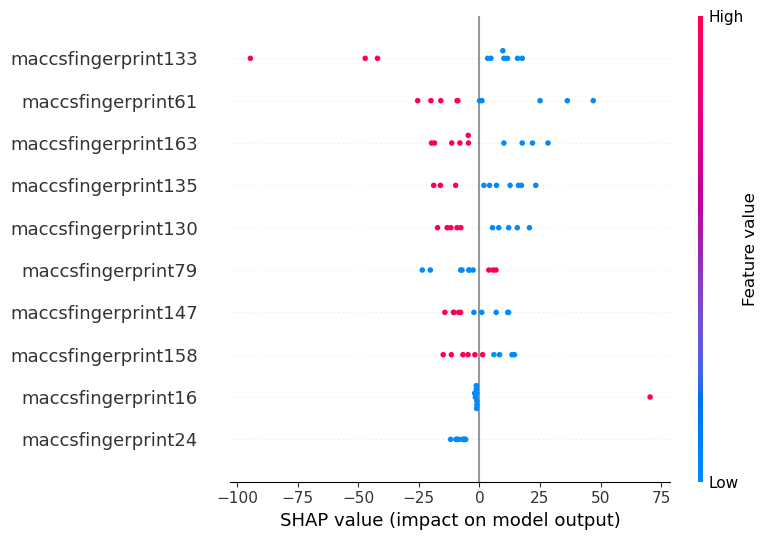

In [22]:
#here it is a more global approach, but it shows how to visualize smarts and connect the features to smarts - I think "translating" this code to local explanations should be okay
shap.summary_plot(shap_f0,
                  test_f0.drop(columns=['capacity_max', 'smiles']),
                  max_display=10,
                  show=True)

In [24]:
feature_names = test_f0.drop(columns=['capacity_max', 'smiles']).columns.tolist()
mean_abs_shap_values = np.mean(np.abs(shap_f0), axis=0)

top_10_indices = np.argsort(mean_abs_shap_values)[-10:][::-1]
top_10_feature_names = [feature_names[i] for i in top_10_indices]

top_10_feature_names

['maccsfingerprint133',
 'maccsfingerprint61',
 'maccsfingerprint163',
 'maccsfingerprint135',
 'maccsfingerprint130',
 'maccsfingerprint79',
 'maccsfingerprint147',
 'maccsfingerprint158',
 'maccsfingerprint16',
 'maccsfingerprint24']

In [38]:
import json

with open('../data/maccs_smarts_mapping.json', 'r') as f:
    smarts_mapping = json.load(f)

smarts_top10 = {feature: smarts_mapping[f'maccsfingerprint{int(feature.replace('maccsfingerprint', '')) + 1}'][0] for feature in top_10_feature_names} #dict from rdkit starts counting from 1, instead of 0
smarts_top10

{'maccsfingerprint133': '[F,Cl,Br,I]',
 'maccsfingerprint61': '*@*!@*@*',
 'maccsfingerprint163': '[#8]',
 'maccsfingerprint135': '[#8]=*',
 'maccsfingerprint130': '[!#6;!#1;!H0]',
 'maccsfingerprint79': '[#7]~*~*~*~[#7]',
 'maccsfingerprint147': '*~[!#6;!#1](~*)~*',
 'maccsfingerprint158': '[#8]',
 'maccsfingerprint16': '[#6]#[#6]',
 'maccsfingerprint24': '[#7]~[#6](~[#7])~[#7]'}

In [39]:
match_molecules = {s: [] for s in smarts_top10.keys()}
for key, value in smarts_top10.items():
    non_zero_molecules = test_f0[test_f0[key] == 1]
    non_zero_molecules = non_zero_molecules['smiles'].tolist()
    match_molecules[key].extend(non_zero_molecules)
match_molecules

{'maccsfingerprint133': ['C#Cc1ccc(N2COc3cc4c(cc3C2)OCN(c2ccc(C#Cc3ccc5c(c3)OCN(c3ccc(N(c6ccc(N7COc8cc(Br)ccc8C7)cc6)c6ccc(N7COc8cc(Br)ccc8C7)cc6)cc3)C5)cc2)C4)cc1',
  'Clc1nc(Cl)nc(-c2ccc(C(c3ccccc3)=c3c4ccccc4c(=C(c4ccccc4)c4ccccc4)c4ccccc34)cc2)n1',
  'OB(O)c1ccc(-c2nc(-c3ccc(B(O)O)cc3)nc(-c3ccc(-c4ccc5c(c4)c4cc(Br)ccc4c4nc6cc7nc8c9ccc(Br)cc9c9cc(Br)ccc9c8nc7cc6nc54)cc3)n2)cc1'],
 'maccsfingerprint61': ['C#Cc1ccc(N2COc3cc4c(cc3C2)OCN(c2ccc(C#Cc3ccc5c(c3)OCN(c3ccc(N(c6ccc(N7COc8cc(Br)ccc8C7)cc6)c6ccc(N7COc8cc(Br)ccc8C7)cc6)cc3)C5)cc2)C4)cc1',
  'Clc1nc(Cl)nc(-c2ccc(C(c3ccccc3)=c3c4ccccc4c(=C(c4ccccc4)c4ccccc4)c4ccccc34)cc2)n1',
  'Nc1ccc(-c2ccc3nc(-c4cc(C(=O)O)cc(-n5c(=O)c6cc7c(=O)n(-c8cc(C(=O)O)cc(C(=O)O)c8)c(=O)c7cc6c5=O)c4)[nH]c3c2)cc1N',
  'Nc1ccc(-c2nc(-c3ccc(N)cc3)nc(-c3ccc(/N=C/c4ccc(N(c5ccc(C=O)cc5)c5ccc(C=O)cc5)cc4)cc3)n2)cc1',
  'OB(O)c1ccc(-c2nc(-c3ccc(B(O)O)cc3)nc(-c3ccc(-c4ccc5c(c4)c4cc(Br)ccc4c4nc6cc7nc8c9ccc(Br)cc9c9cc(Br)ccc9c8nc7cc6nc54)cc3)n2)cc1'],
 'maccsfingerpri

maccsfingerprint133 [F,Cl,Br,I]


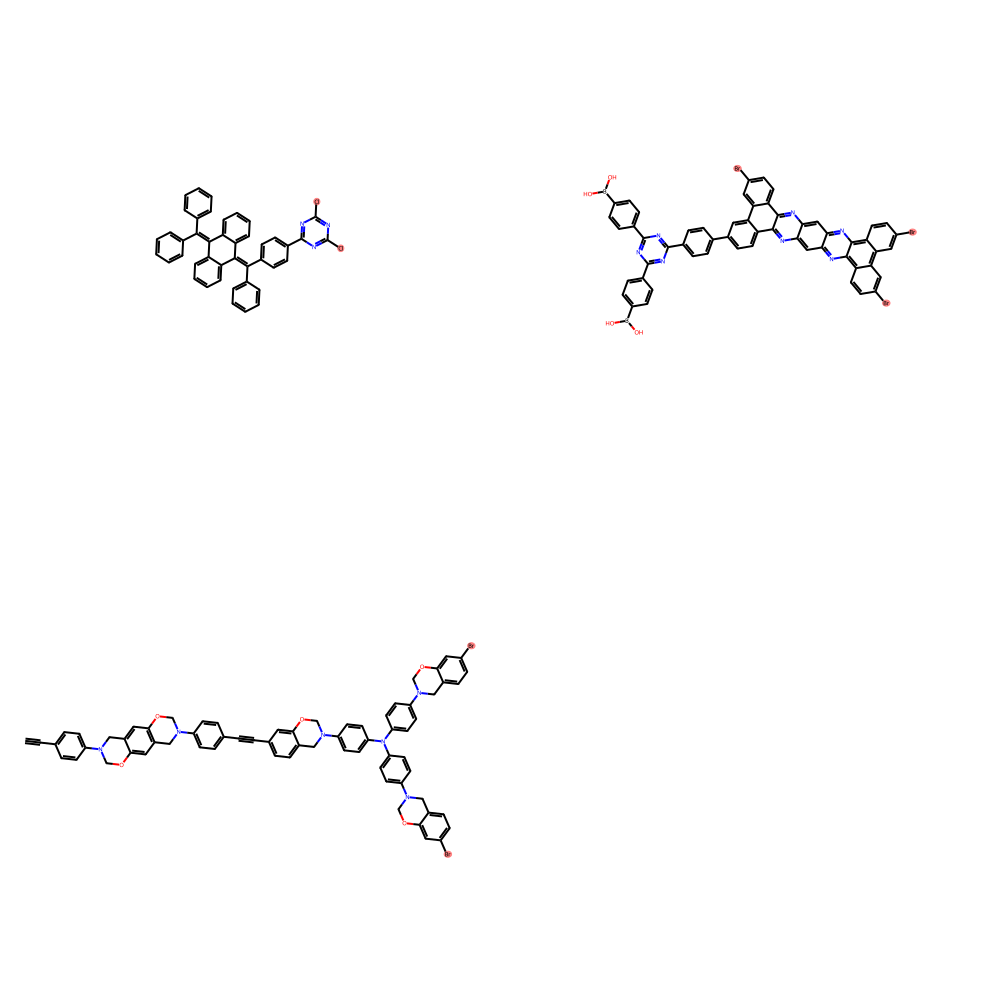

maccsfingerprint61 *@*!@*@*


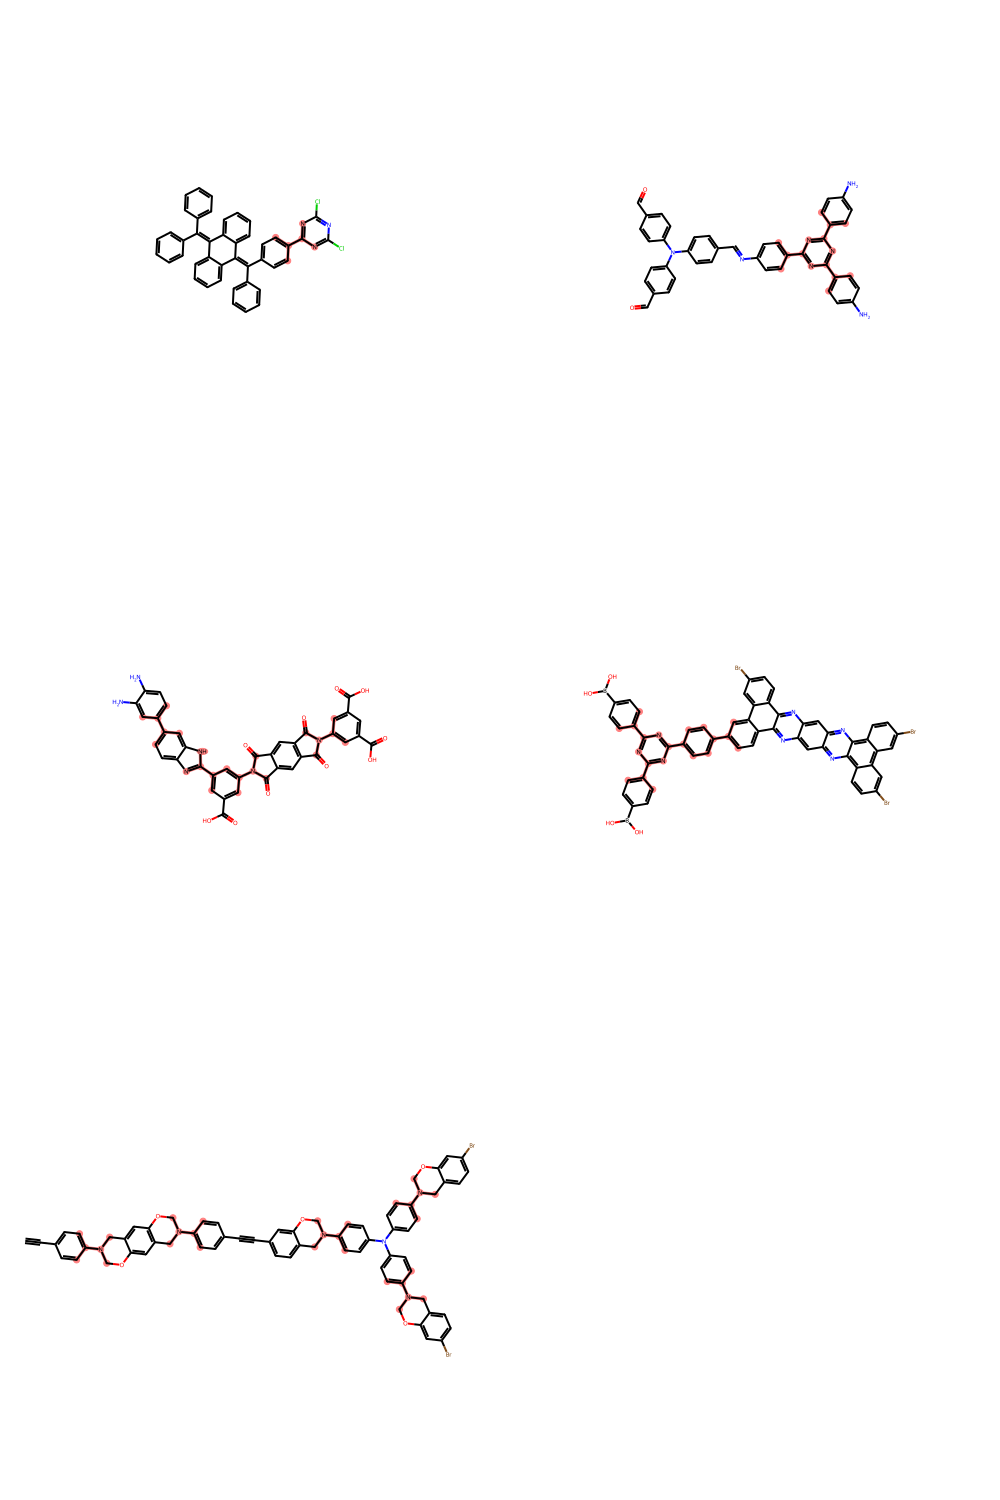

maccsfingerprint163 [#8]


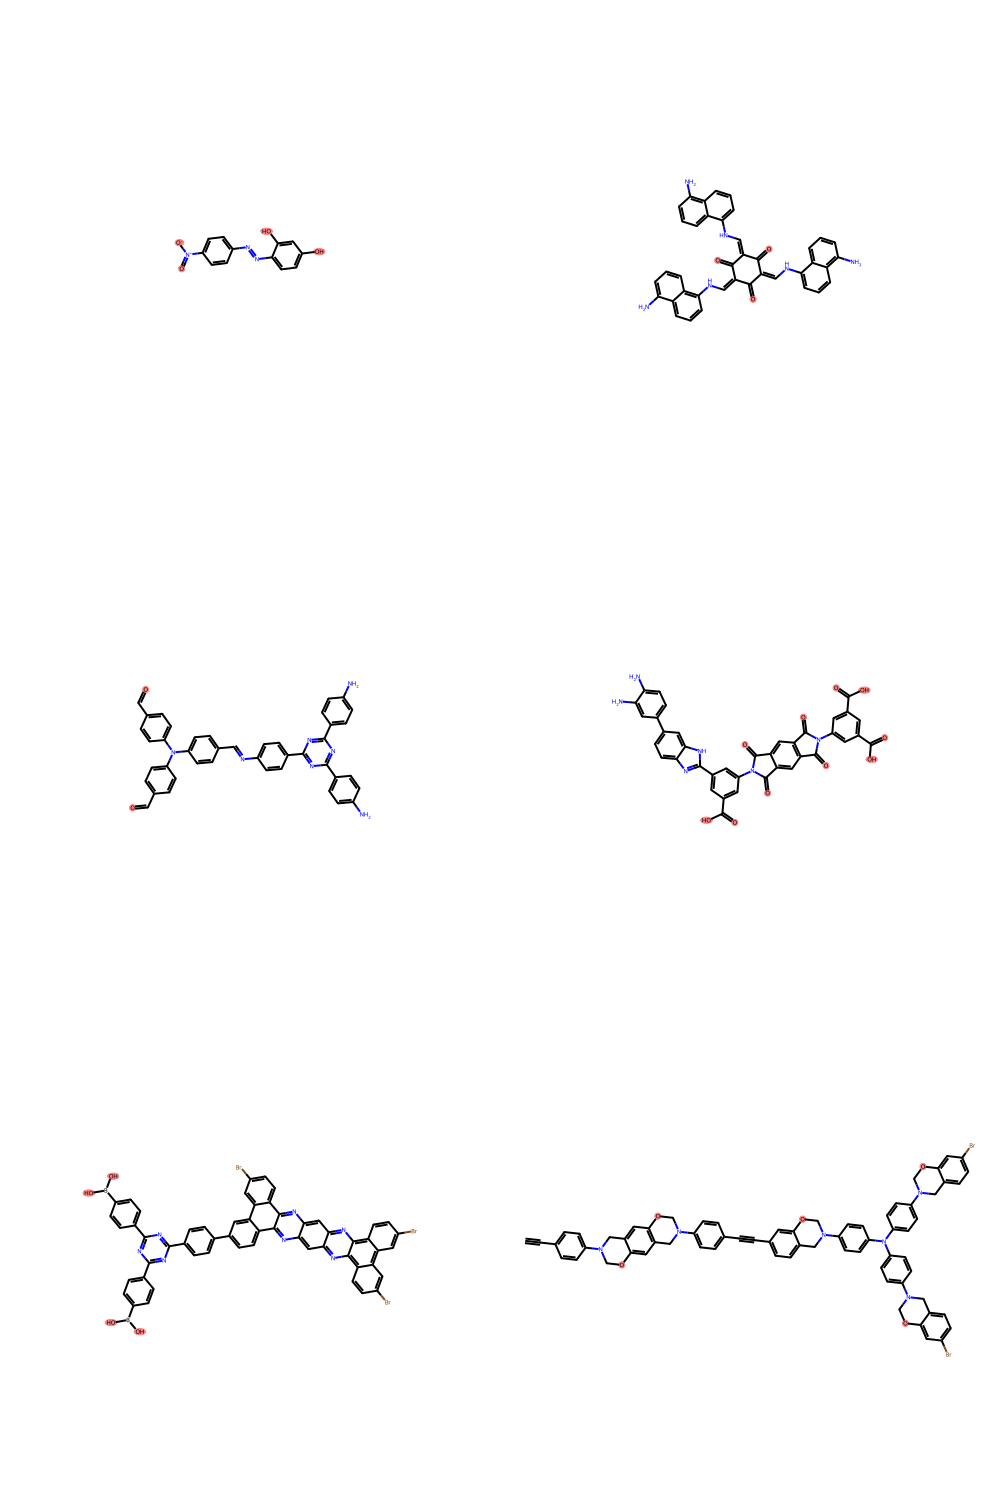

maccsfingerprint135 [#8]=*


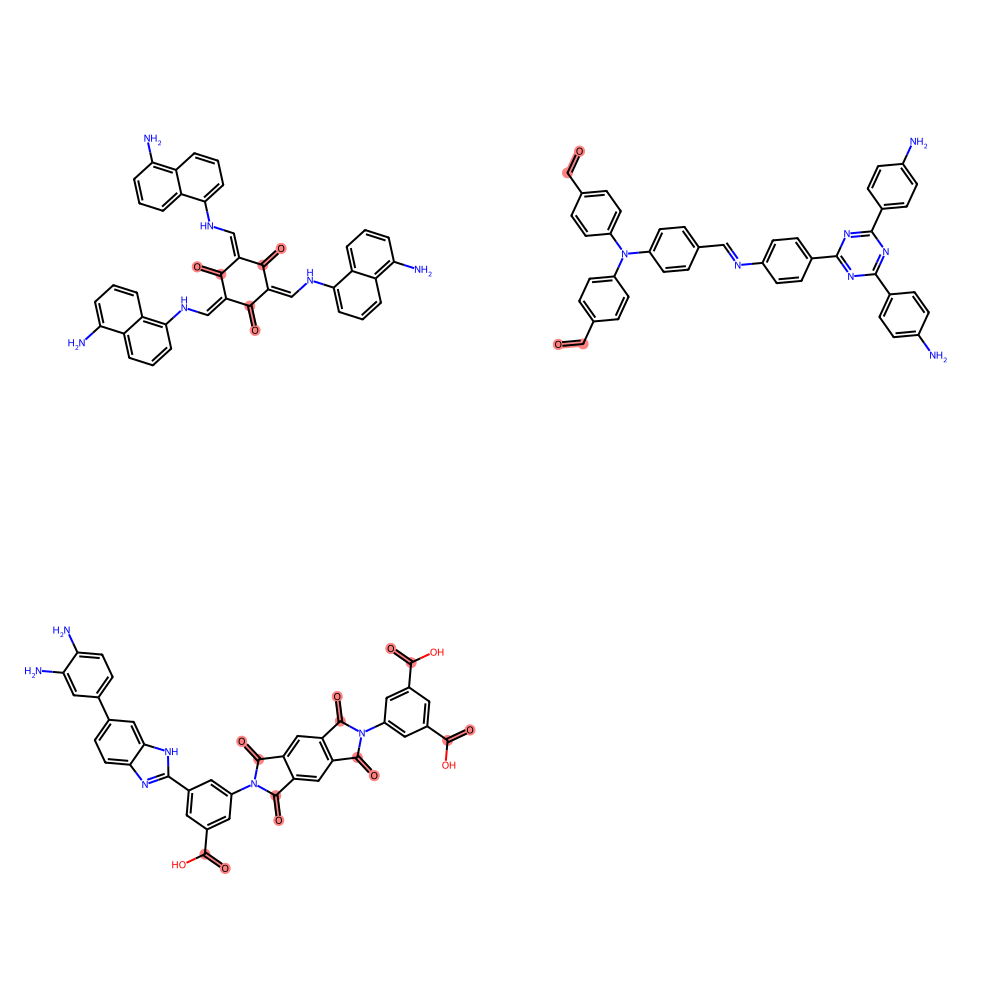

maccsfingerprint130 [!#6;!#1;!H0]


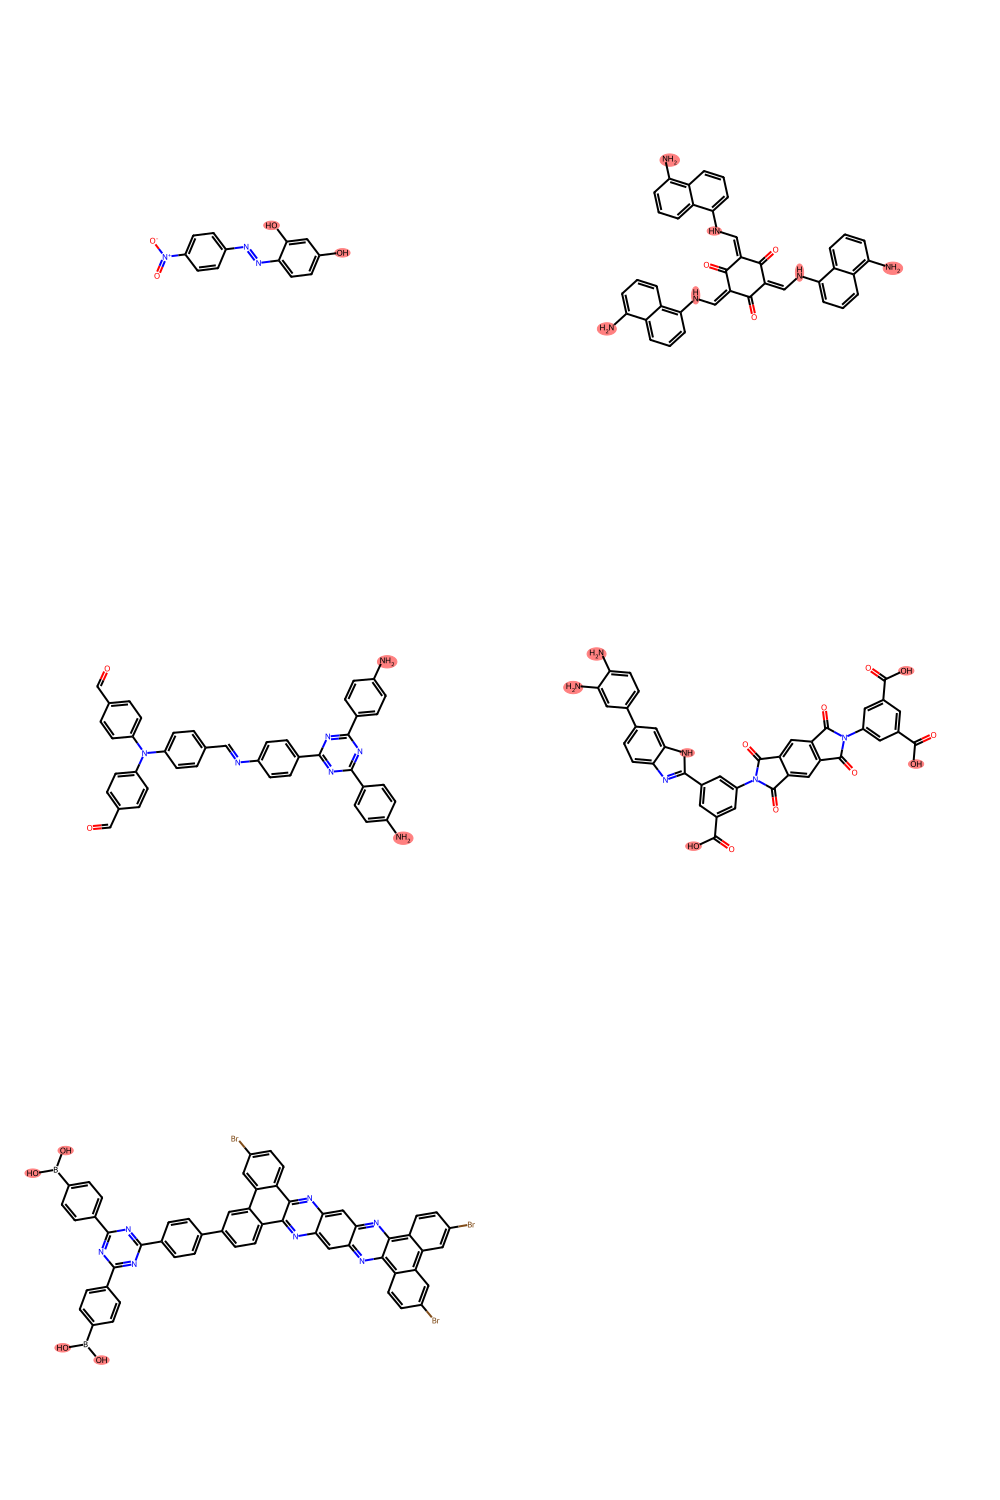

maccsfingerprint79 [#7]~*~*~*~[#7]


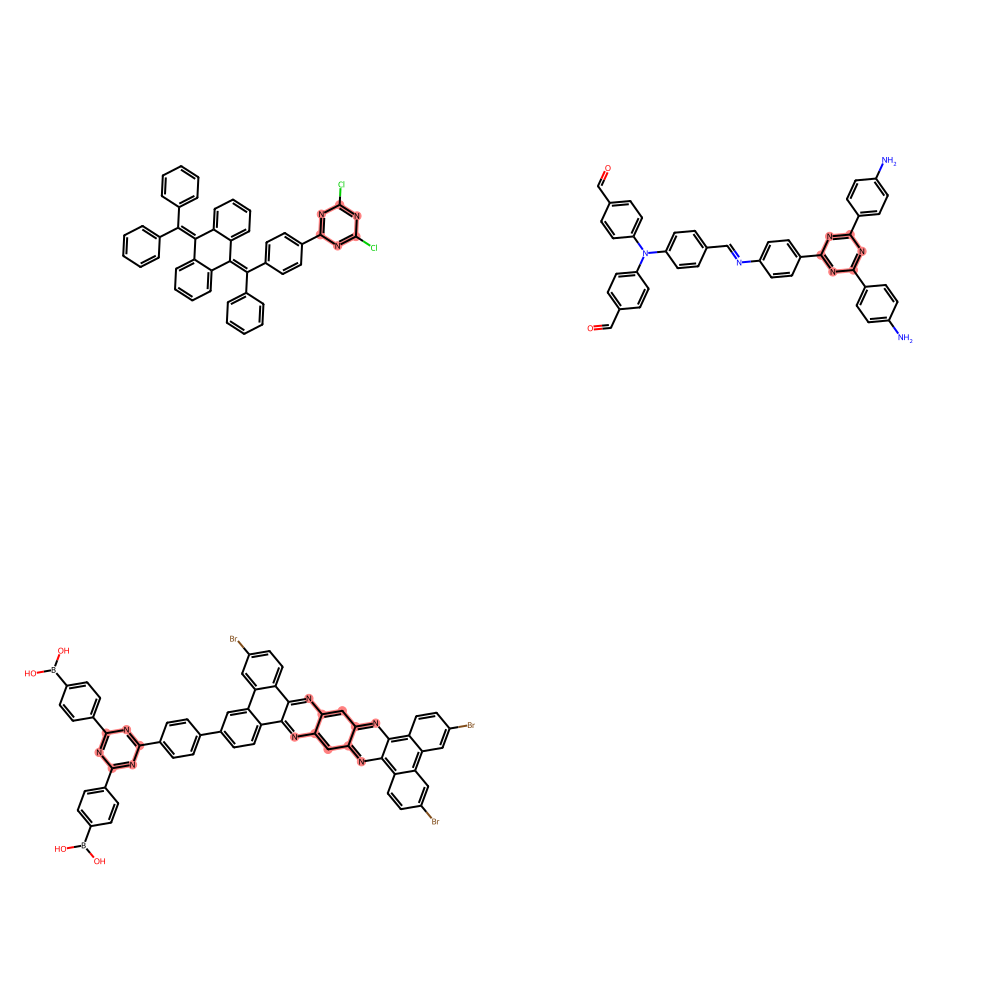

maccsfingerprint147 *~[!#6;!#1](~*)~*


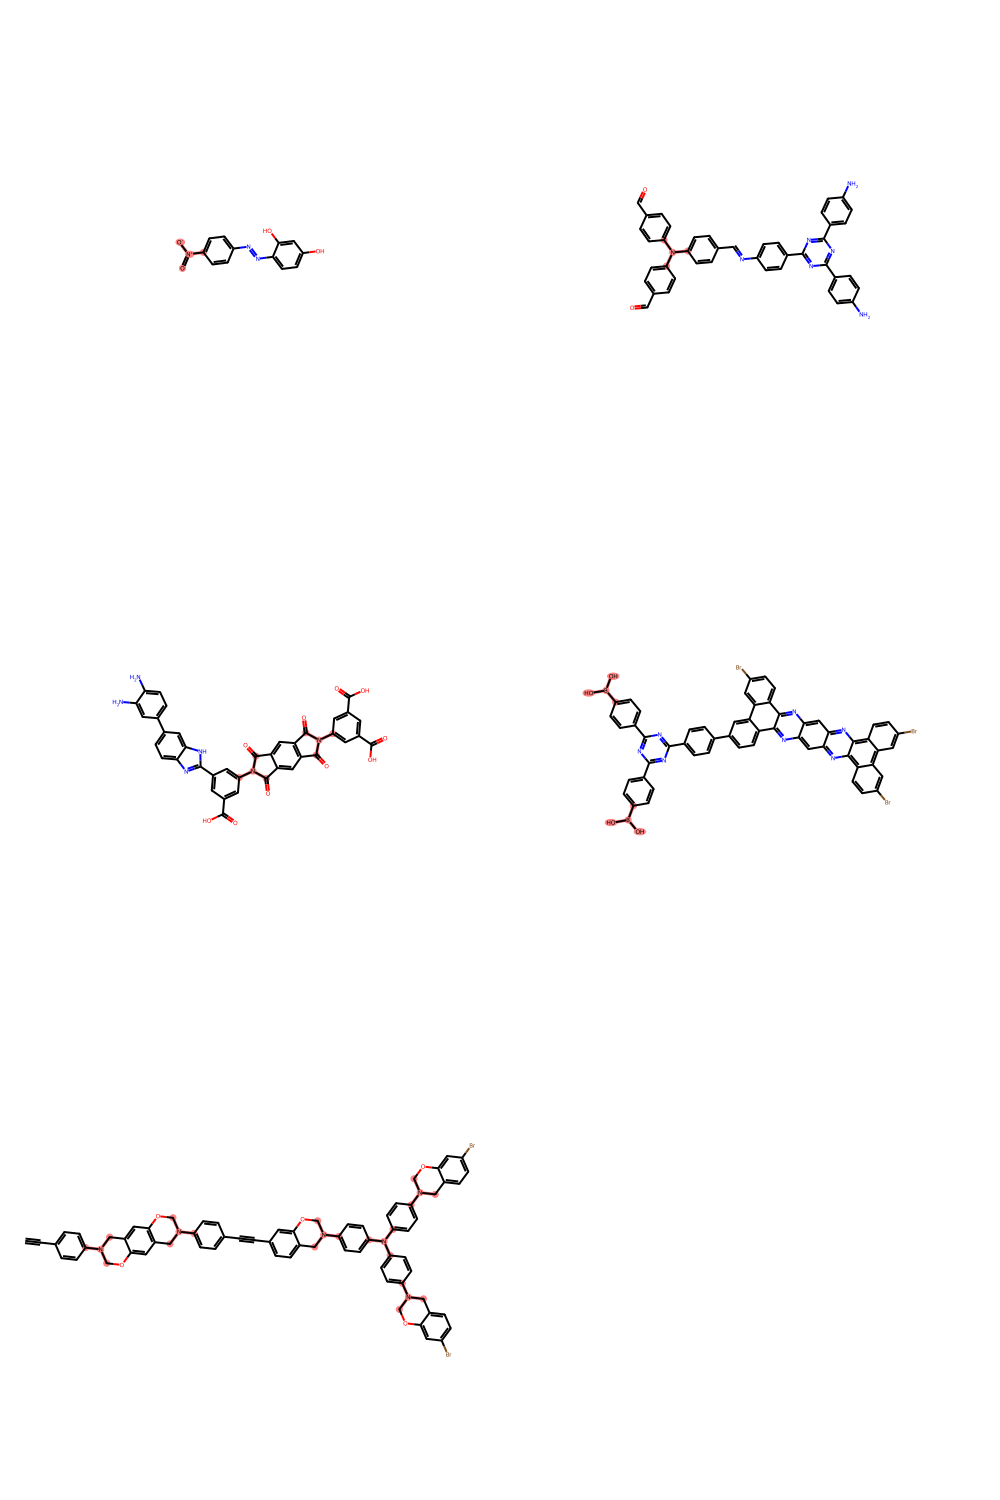

maccsfingerprint158 [#8]


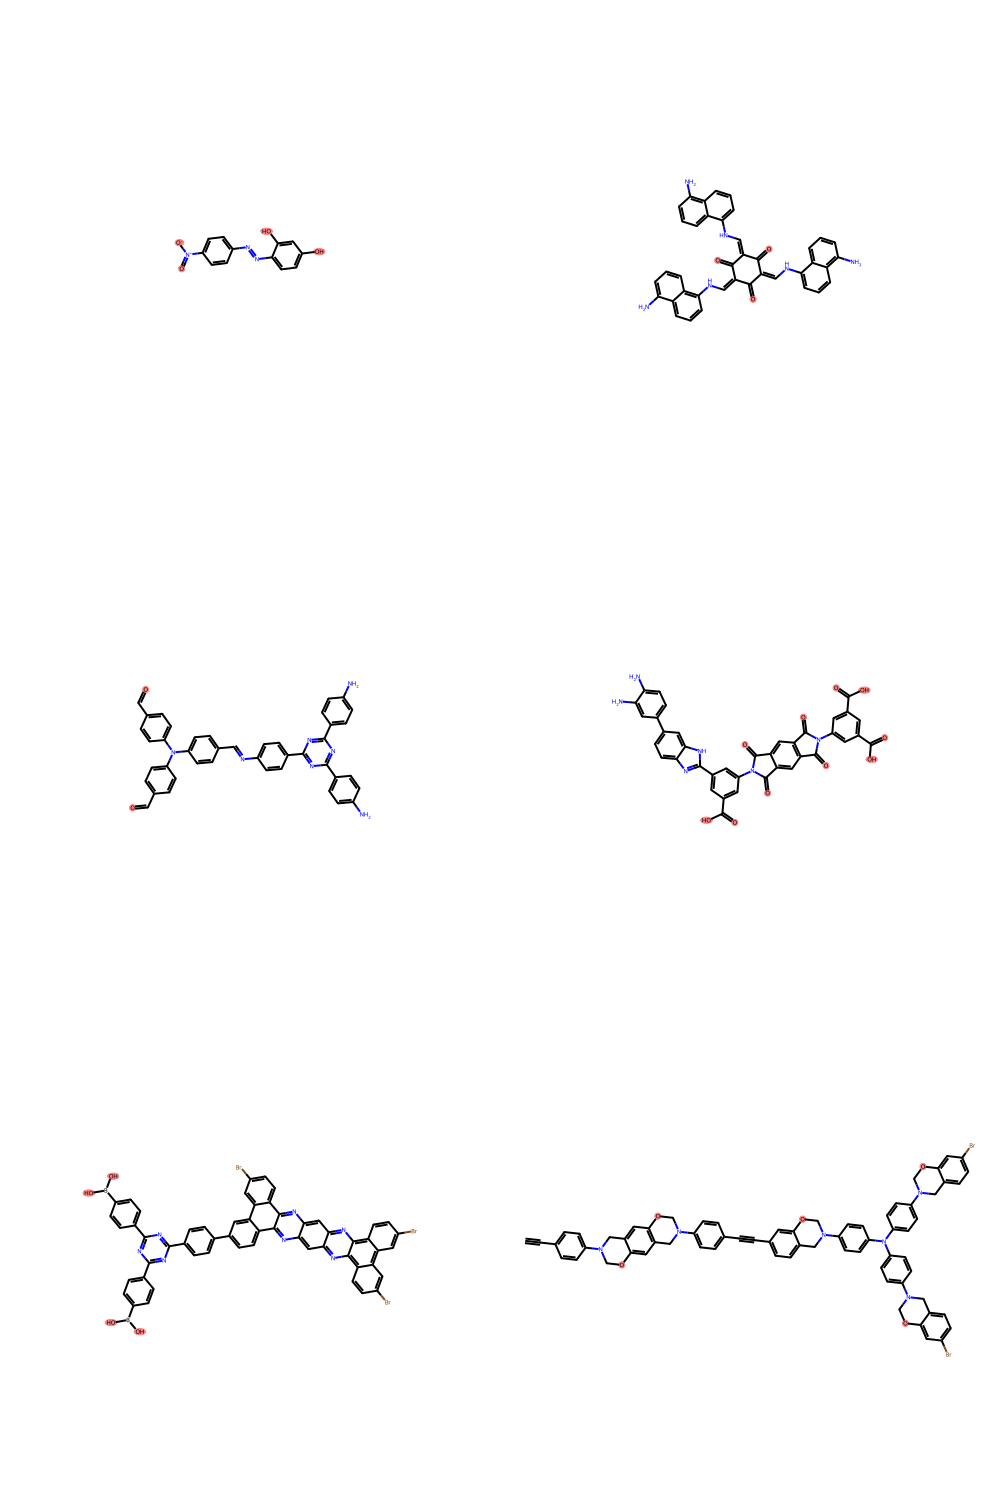

maccsfingerprint16 [#6]#[#6]


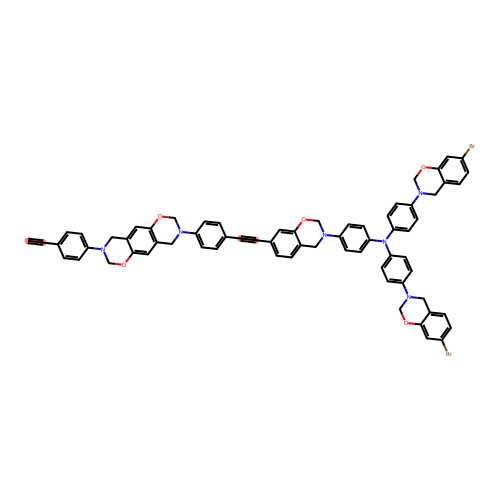

maccsfingerprint24 [#7]~[#6](~[#7])~[#7]


In [68]:
from rdkit import Chem
from rdkit.Chem import Draw

for key in match_molecules.keys():
    print(key, smarts_top10[key])
    if len(match_molecules[key]) == 0:
        continue
    mols = [Chem.MolFromSmiles(smi) for smi in sorted(match_molecules[key], key=lambda x: len(x))]
    match_smart = Chem.MolFromSmarts(smarts_top10[key])
    highlight_lists = [mol.GetSubstructMatches(match_smart) for mol in mols]
    highlight_lists = [[atom for sublist in highlight for atom in sublist] for highlight in highlight_lists]
    img = Draw.MolsToGridImage(
        mols,
        highlightAtomLists=highlight_lists,
        molsPerRow=min(len(mols), 2),
        subImgSize=(500, 500),
    )
    display(img)
